In [1]:
! pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.8 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import *
from fastbook import *

## Image Classification

### 3 or more categories

We've already seen how to approach binary classification problems where the model is supposed to label the input as either one class or another. The next step we'll tackle here is doing that when there are more than 2 possible classes. In other words, label the input data as one of three or more possible classes.

In [3]:
path = untar_data(URLs.PETS)
path

<div><progress max="811706944" value="811712512"></progress> 100.00% [811712512/811706944 00:20&lt;00:00]</div>

Path('/root/.fastai/data/oxford-iiit-pet')

Centralize path traversal to the dataset location.

In [4]:
Path.BASE_PATH = path
Path.BASE_PATH

Path('.')

In [5]:
path.ls()

[Path('images'), Path('annotations')]

The `annotations/` folder contains location data, which is not relevant here. We care about classifying the images based on their visual features.

In [6]:
(path/'images').ls()

(#7393) [Path('images/beagle_115.jpg'), Path('images/boxer_18.jpg'), Path('images/Maine_Coon_157.jpg'), Path('images/scottish_terrier_28.jpg'), Path('images/english_setter_6.jpg'), Path('images/american_pit_bull_terrier_79.jpg'), Path('images/boxer_128.jpg'), Path('images/Persian_265.jpg'), Path('images/Maine_Coon_182.jpg'), Path('images/keeshond_89.jpg'), Path('images/chihuahua_82.jpg'), Path('images/basset_hound_5.jpg'), Path('images/english_cocker_spaniel_144.jpg'), Path('images/scottish_terrier_108.jpg'), Path('images/British_Shorthair_116.jpg'), Path('images/boxer_10.jpg'), Path('images/basset_hound_194.jpg'), Path('images/beagle_85.jpg'), Path('images/japanese_chin_87.jpg'), Path('images/pug_40.jpg'), Path('images/chihuahua_199.jpg'), Path('images/english_setter_152.jpg'), Path('images/Bengal_98.jpg'), Path('images/chihuahua_174.jpg'), Path('images/leonberger_166.jpg'), Path('images/german_shorthaired_68.jpg'), Path('images/miniature_pinscher_27.jpg'), Path('images/Ragdoll_257.jp

The file names contain the label and an index of that file in the list for the breed. So we need to extract that label carefully.

In [7]:
fname = (path/'images').ls()[0]
re.findall(r'(.+)_\d+\.jpg', fname.name)

['beagle']

Works well enough. Now we'll apply it to the full dataset. We'll use `RegexLabeller` in a `DataBlock` because `DataBlock` is our go-to method for organizing the data into data loaders.

In [8]:
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=using_attr(RegexLabeller(r'(.+)_\d+\.jpg'), 'name'),
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
)
pets

Trying to view the data using `pets.dataloaders(path/'images').show_batch(nrows=1, ncols=3)` will generate the following error:

```
---------------------------------------------------------------------------
RuntimeError                              Traceback (most recent call last)
/tmp/ipykernel_57/3554155714.py in <cell line: 0>()
----> 1 pets.dataloaders(path/'images').show_batch(nrows=1, ncols=3)

/usr/local/lib/python3.12/dist-packages/fastai/data/core.py in show_batch(self, b, max_n, ctxs, show, unique, **kwargs)
    154             old_get_idxs = self.get_idxs
    155             self.get_idxs = lambda: Inf.zeros
--> 156         if b is None: b = self.one_batch()
    157         if not show: return self._pre_show_batch(b, max_n=max_n)
    158         show_batch(*self._pre_show_batch(b, max_n=max_n), ctxs=ctxs, max_n=max_n, **kwargs)

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in one_batch(self)
    187     def one_batch(self):
    188         if self.n is not None and len(self)==0: raise ValueError(f'This DataLoader does not contain any batches')
--> 189         with self.fake_l.no_multiproc(): res = first(self)
    190         if hasattr(self, 'it'): delattr(self, 'it')
    191         return res

/usr/local/lib/python3.12/dist-packages/fastcore/basics.py in first(x, f, negate, **kwargs)
    760     x = iter(x)
    761     if f: x = filter_ex(x, f=f, negate=negate, gen=True, **kwargs)
--> 762     return next(x, None)
    763 
    764 # %% ../nbs/01_basics.ipynb #65009551

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in __iter__(self)
    127         self.before_iter()
    128         self.__idxs=self.get_idxs() # called in context of main process (not workers/subprocesses)
--> 129         for b in _loaders[self.fake_l.num_workers==0](self.fake_l):
    130             # pin_memory causes tuples to be converted to lists, so convert them back to tuples
    131             if self.pin_memory and type(b) == list: b = tuple(b)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py in __next__(self)
    739                 # TODO(https://github.com/pytorch/pytorch/issues/76750)
    740                 self._reset()  # type: ignore[call-arg]
--> 741             data = self._next_data()
    742             self._num_yielded += 1
    743             if (

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py in _next_data(self)
    799     def _next_data(self):
    800         index = self._next_index()  # may raise StopIteration
--> 801         data = self._dataset_fetcher.fetch(index)  # may raise StopIteration
    802         if self._pin_memory:
    803             data = _utils.pin_memory.pin_memory(data, self._pin_memory_device)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/fetch.py in fetch(self, possibly_batched_index)
     42                 raise StopIteration
     43         else:
---> 44             data = next(self.dataset_iter)
     45         return self.collate_fn(data)
     46 

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in create_batches(self, samps)
    138         if self.dataset is not None: self.it = iter(self.dataset)
    139         res = filter(lambda o:o is not None, map(self.do_item, samps))
--> 140         yield from map(self.do_batch, self.chunkify(res))
    141 
    142     def new(self, dataset=None, cls=None, **kwargs):

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in do_batch(self, b)
    183             if not self.prebatched: collate_error(e,b)
    184             raise
--> 185     def do_batch(self, b): return self.retain(self.create_batch(self.before_batch(b)), b)
    186     def to(self, device): self.device = device
    187     def one_batch(self):

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in create_batch(self, b)
    181         try: return (fa_collate,fa_convert)[self.prebatched](b)
    182         except Exception as e:
--> 183             if not self.prebatched: collate_error(e,b)
    184             raise
    185     def do_batch(self, b): return self.retain(self.create_batch(self.before_batch(b)), b)

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in create_batch(self, b)
    179         else: raise IndexError("Cannot index an iterable dataset numerically - must use `None`.")
    180     def create_batch(self, b):
--> 181         try: return (fa_collate,fa_convert)[self.prebatched](b)
    182         except Exception as e:
    183             if not self.prebatched: collate_error(e,b)

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in fa_collate(t)
     52     b = t[0]
     53     return (default_collate(t) if isinstance(b, _collate_types)
---> 54             else type(t[0])([fa_collate(s) for s in zip(*t)]) if isinstance(b, Sequence)
     55             else default_collate(t))
     56 

/usr/local/lib/python3.12/dist-packages/fastai/data/load.py in fa_collate(t)
     51     "A replacement for PyTorch `default_collate` which maintains types and handles `Sequence`s"
     52     b = t[0]
---> 53     return (default_collate(t) if isinstance(b, _collate_types)
     54             else type(t[0])([fa_collate(s) for s in zip(*t)]) if isinstance(b, Sequence)
     55             else default_collate(t))

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/collate.py in default_collate(batch)
    399         >>> default_collate(batch)  # Handle `CustomType` automatically
    400     """
--> 401     return collate(batch, collate_fn_map=default_collate_fn_map)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/collate.py in collate(batch, collate_fn_map)
    157         for collate_type in collate_fn_map:
    158             if isinstance(elem, collate_type):
--> 159                 return collate_fn_map[collate_type](
    160                     batch, collate_fn_map=collate_fn_map
    161                 )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/_utils/collate.py in collate_tensor_fn(batch, collate_fn_map)
    273         storage = elem._typed_storage()._new_shared(numel, device=elem.device)
    274         out = elem.new(storage).resize_(len(batch), *list(elem.size()))
--> 275     return torch.stack(batch, 0, out=out)
    276 
    277 

/usr/local/lib/python3.12/dist-packages/fastai/torch_core.py in __torch_function__(cls, func, types, args, kwargs)
    382         if cls.debug and func.__name__ not in ('__str__','__repr__'): print(func, types, args, kwargs)
    383         if _torch_handled(args, cls._opt, func): types = (torch.Tensor,)
--> 384         res = super().__torch_function__(func, types, args, ifnone(kwargs, {}))
    385         dict_objs = _find_args(args) if args else _find_args(list(kwargs.values()))
    386         if issubclass(type(res),TensorBase) and dict_objs: res.set_meta(dict_objs[0],as_copy=True)

/usr/local/lib/python3.12/dist-packages/torch/_tensor.py in __torch_function__(cls, func, types, args, kwargs)
   1701 
   1702         with _C.DisableTorchFunctionSubclass():
-> 1703             ret = func(*args, **kwargs)
   1704             if func in get_default_nowrap_functions():
   1705                 return ret

RuntimeError: Error when trying to collate the data into batches with fa_collate, at least two tensors in the batch are not the same size.

Mismatch found on axis 0 of the batch and is of type `TensorImage`:
	Item at index 0 has shape: torch.Size([3, 335, 500])
	Item at index 1 has shape: torch.Size([3, 375, 500])

Please include a transform in `after_item` that ensures all data of type TensorImage is the same size

```

That error message highlights the importance of transforming all the input data into the same size!

#### Presizing

The idea here is to perform different manipulation operations that will generate the final set of images that constitute the training and validation data. Of course the data must be the same size so they can all work well with the tensor format used by the model. In this process, we have an incentive to:
1. minimize the augmentation operations performed on the images, because that reduces the computational effort required to generate the dataset while also minimizing the number of lossy or pixel-destructive operations performed on the original data
2. perform these operations in groups/batches to take advantage of the GPU's parallelism

As mentioned earlier, a lot of the augmentation operations can destroy the details of some pixels (eg skew) or create empty zones where nothing is happening (eg rotation). So performing the augmentation operations after resizing to the final size would leave no way to do anything about these losses. One solution is to resize to an initial larger size, apply the transformations, then resize to the final smaller size.

In this fastai this is done by applying the initial resize in the CPU using `item_tfms`, then performing the augmentation and final resize operations in batches using `batch_tfms`. The initial resize is done image-by-image on the CPU because the GPU is where the images need to be the same size. Also note that the augmentations are not performed on the validation set, only the resize to the final size.

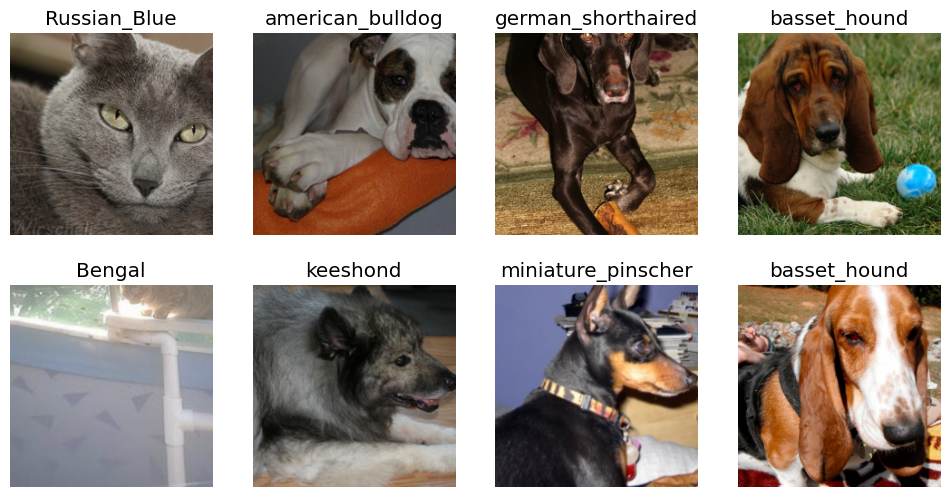

In [9]:
pets = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,
    get_y=using_attr(RegexLabeller(r'(.+)_\d+\.jpg'), 'name'),
    splitter=RandomSplitter(seed=42),
    item_tfms=Resize(460),
    batch_tfms=aug_transforms(min_scale=0.75, size=224)
)
pets.dataloaders(path/'images').show_batch(nrows=2, ncols=4)

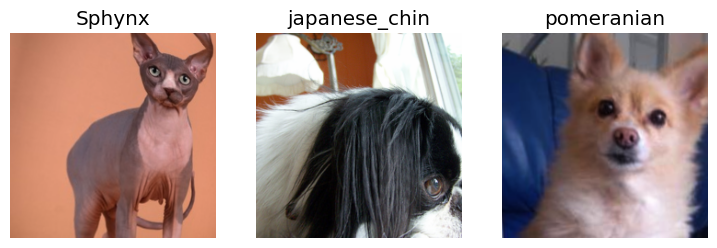

In [10]:
pets.dataloaders(path/'images').train.show_batch(nrows=1, ncols=3)

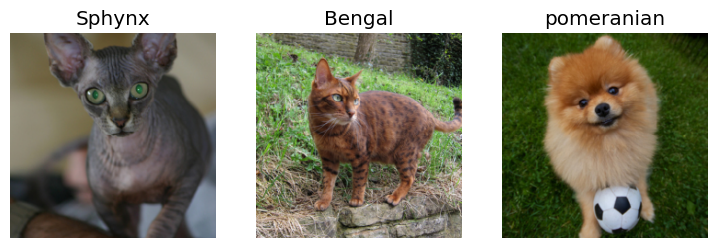

In [11]:
pets.dataloaders(path/'images').valid.show_batch(nrows=1, ncols=3)

Use the `.summary()` method on the data block to get details (and errors) on how a batch is built.

In [12]:
pets.summary(path/'images')

Setting-up type transforms pipelines
Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}


Building one sample
  Pipeline: PILBase.create
    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying PILBase.create gives
      PILImage mode=RGB size=333x500
  Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

    starting from
      /root/.fastai/data/oxford-iiit-pet/images/basset_hound_43.jpg
    applying partial gives
      basset_hound
    applying Categorize -- {'vocab': None, 'sort': True, 'add_na': False}
 gives
      TensorCategory(14)

Final sample: (PILImage mode=RGB size=333x500, TensorCategory(14))


Found 7390 items
2 datasets of sizes 5912,1478
Setting up Pipeline: PILBase.create
Setting up Pipeline: partial -> Categorize -- {'vocab': None, 'sort': True, 'add_na': False}

Setting up 

Once the datablock can build successively, it's best to train a small model just to get a feel for what you have on your hands.

In [13]:
dls = pets.dataloaders(path/'images')

In [14]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2)

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 239MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.509593,0.367904,0.108931,00:35


epoch,train_loss,valid_loss,error_rate,time
0,0.484104,0.316959,0.106225,00:42
1,0.335560,0.239994,0.075101,00:43


Note that no loss function is specified, yet loss values were calculated. What happened?

Fastai picks a sensible default loss function based on the data in the dataloader. In this case, the dataloaders yields more than 3 categories, so it's a safe bet to use **cross-entropy loss** on the assumption that this is a multilabel single classification problem.

### Cross-Entropy Loss

This is similar to the one used in Chapter 4, but it's particularly appropriate when there are 3 or more possible categories. It's important to start by understanding the inputs that will go into the loss function, which is the model predictions and the target values or labels.

#### Activations and labels

For multilabel classification, the final layer of the model will output a set of predictions for each category to be classified. These predictions will be numbers, specifically **logits** (or activations), coming from a linear function for that specific category. As we saw in a previous chapter, the logits are numbers between ➖∞ and ➕∞. And as we already know, we'll need to convert them to probabilities representing a confidence that the input data should be categorized as a member of a particular class. To see what these numbers are, we need to actually get them from the model. The `.get_preds()` method from the `Learner` object will give us the **probabilities** (not the logits) from the final layer, but that method accepts a pair of input values and target labels.

We can get an input-target pair from the dataloader:

In [15]:
x,y = dls.one_batch()
x.shape, y, y.shape

(torch.Size([64, 3, 224, 224]),
 TensorCategory([28,  4, 29, 21,  1, 28, 27, 30, 34, 36, 30, 32,  6,  5, 35, 15, 11, 20, 24, 11, 25,  7, 20, 18,  0,  9, 22,  0, 24, 19, 23, 21, 32, 31, 18, 34, 33, 16, 21, 33, 18, 34, 16, 26, 21, 30,
                  1, 20, 35,  7, 25, 30, 24, 23, 24, 32, 35,  9, 25, 15, 34, 11,  5,  5], device='cuda:0'),
 torch.Size([64]))

`.one_batch()` returns the input-target pairs for a mini-batch. We can use these values directly in `.get_preds()`:

In [16]:
preds,_ = learn.get_preds(dl=[(x, y)])
preds[0], preds[0].shape

(tensor([5.4056e-09, 4.7154e-09, 2.8041e-06, 8.9139e-08, 1.1486e-07, 3.7010e-08, 3.3207e-07, 4.0671e-06, 2.6503e-06, 3.7322e-07, 1.9840e-08, 1.7664e-07, 1.9399e-08, 2.0383e-08, 6.4872e-08, 2.3469e-07,
         1.4062e-07, 3.7893e-06, 2.2359e-07, 1.0298e-07, 5.9509e-08, 1.2620e-07, 5.6700e-06, 2.0714e-04, 4.7195e-05, 3.7376e-07, 1.8673e-07, 5.2194e-07, 9.9971e-01, 1.4112e-06, 8.2669e-08, 1.0311e-05,
         3.2317e-07, 3.9269e-06, 2.9886e-08, 8.7677e-08, 1.2946e-06]),
 torch.Size([37]))

Note: the `_` is used to skip the second member of the result tuple from `get_preds` because it's the target labels, which we already have in `y`.

As we can see, the values in `preds` are all between 0 and 1, and all the values are pretty close to 0, except for of them that is pretty close to 1. Crucially, they all sum up to exactly 1:

In [17]:
preds[0].sum()

tensor(1.0000)

We need to understand how the logits were transformed into this probability. Enter the softmax activation function.

#### Softmax

To build up intuition around this function, let's go back to the sigmoid function that was used in the previous chapter when we worked with a binary classification problem, that's to say, each input image had to be 1 category or the other.

In that case, the sigmoid function served as a mechanism for converting a particular logit/activation into a probability value, the probability that the input was a particular class. And because there could be only one other option, the inverse of that probability was the probability of the other class. So the single logit provided by the final linear function in the model represented the model's confidence that the input belonged to the single target class.

If we change our view slightly and introduce a second linear function in the final layer, this second function will similarly output a logit indicating the model's confidence that the input belongs to the second category. At this point, however, if we use the sigmoid function on each logit, we can no longer reliably treat the inverse of the result of the first category as the probability of the second class. It would be better to go with the probability provided by the second linear function whose weights have been specifically attuned to identifying the second class. More so, because our objective is to pick only one label out of 2 (meaning the input can only be one of the 2 categories), we need to take extra steps to make sure the 2 probabilities actually add up to 1, to force the model to get good at picking only one of the 2. The final layer of the model wouldn't ensure that on its own.

To see how this could appear, consider a tensor containing the logits from the final layer for 6 images, where there are 2 possible categories. We'll use a randomly generated set of logits just for illustration:

In [18]:
# first make sure the "randomness" is reproducible
torch.random.manual_seed(42)

In [19]:
logits = torch.randn((6,2)) * 2
logits

tensor([[ 0.6734,  0.2576],
        [ 0.4689,  0.4607],
        [-2.2457, -0.3727],
        [ 4.4164, -1.2760],
        [ 0.9233,  0.5347],
        [ 1.0698,  1.6187]])

We multiplied by 2 to increase the range of the numbers from `-1,1` to `-2,2`. Each vector of 2 elements represents the logits for the 2 categories coming from the final layer of the model.

Now here's what happens if we pass those values into the sigmoid function, along with the sum of each pair's values:

In [20]:
logits.sigmoid(), logits.sigmoid().sum(-1)

(tensor([[0.6623, 0.5641],
         [0.6151, 0.6132],
         [0.0957, 0.4079],
         [0.9881, 0.2182],
         [0.7157, 0.6306],
         [0.7446, 0.8346]]),
 tensor([1.2263, 1.2283, 0.5036, 1.2063, 1.3463, 1.5792]))

None of them adds up to 1. This is why we can't rely on the sigmoid function here.

Stepping back, another way to look at the logits is as a measure of the model's *relative* confidence that the input belongs to the corresponding category when the 2 numbers are compared to each other. In other words, the higher logit indicates that the model is more confident that the input image belongs to that logit's category, and the distance between that logit and the other is a reflection of how much more confident the model is compared to the other class. Let's calculate the difference between the 2 pairs of logits:

In [21]:
logits[:,0] - logits[:,1]

tensor([ 0.4158,  0.0083, -1.8731,  5.6924,  0.3886, -0.5489])

There are large gaps between the values. For illustration, let's compare the first and second values, which are the differences in logits for the first and second images. With a difference of `0.4158`, it's obvious that the model is more *relatively* confident that the input image belongs to the first category instead of the other, compared to the second image where the model made much closer predictions that led to a difference of just `0.0083` which indicates less *relative* confidence. Similarly, the third number (corresponding to the third image) indicates that the model is more *relatively* confident that the image belongs to the second category rather than the first; that's what the negative number means.

Following from that realization, it's actually quite intuitive to then feed these differences into the sigmoid function. After all, much like the underlying logits, they represent a measure of the model's inclination towards one category compared to the other, and the bigger that difference, the more strongly the model inclines towards one of the categories.

Now let's pass those differences into the sigmoid function:

In [22]:
(logits[:,0] - logits[:,1]).sigmoid()

tensor([0.6025, 0.5021, 0.1332, 0.9966, 0.5959, 0.3661])

Those probabilities make a lot of sense. For instance, the difference of `-1.8731` for the first image turns into a probability of `0.1332`, which indicates low confidence in the first category and therefore high confidence in the second (`1-0.1332 = 0.8668`). Same for all the other 6 values. At this stage, we can represent this sigmoid operation mathematically as follows:

$$p_{1} = \frac{1}{1+e^{-(z_{1}-z_{2})}}$$

where $z_{1}$ and $z_{2}$ are the respective logits for categories 1 and 2. Things get more interesting if we expand this equation algebraically:

$$p_{1} = \frac{1}{1+e^{-(z_{1}-z_{2})}} = \frac{1}{1+e^{(z_{2}-z_{1})}} = \frac{1}{1 + \frac{e^{z_{2}}}{e^{z_{1}}}} = \frac{1}{\frac{e^{z_{1}}}{e^{z_{1}}} + \frac{e^{z_{2}}}{e^{z_{1}}}} = \frac{1}{\frac{e^{z_{1}} + e^{z_{2}}}{e^{z_{1}}}}$$

We can now multiply the numerator and denominator by $e^{z_{1}}$ to remove the fraction in the denominator:

$$p_{1} = \frac{1}{\frac{e^{z_{1}} + e^{z_{2}}}{e^{z_{1}}}} * \frac{e^{z_{1}}}{e^{z_{1}}} = \frac{e^{z_{1}}}{e^{z_{1}} + e^{z_{2}}}$$

Now that final form $\frac{e^{z_{1}}}{e^{z_{1}} + e^{z_{2}}}$ is actually the standard form of the softmax function! More accurately, it's the form of softmax when there are 2 categories involved. The key insight is to recognize that the probability is obtained by normalizing the exponentiated logits relative to each other. In other words, the "whole probability" for all categories is always the sum of the exponentiated logits of each category, and the probability for any given category is its proportion of that whole.

It therefore becomes very easy to see that for a classification model that outputs 3 categories, softmax would be:

$$p_{1} = \frac{e^{z_{1}}}{e^{z_{1}} + e^{z_{2}} + e^{z_{3}}}$$

And for 4 categories it would be:

$$p_{1} = \frac{e^{z_{1}}}{e^{z_{1}} + e^{z_{2}} + e^{z_{3}} + e^{z_{4}}}$$

And on and on for $n$ categories:

$$p_{n} = \frac{e^{z_{n}}}{e^{z_{1}} + e^{z_{2}} + e^{z_{3}} + e^{z_{4}}… + e^{z_{n}}}$$

In python that looks like this:

In [23]:
def softmax(x):
    return torch.exp(x) / torch.exp(x).sum(1, keepdim=True)

In [24]:
sm_logits = softmax(logits)
sm_logits

tensor([[0.6025, 0.3975],
        [0.5021, 0.4979],
        [0.1332, 0.8668],
        [0.9966, 0.0034],
        [0.5959, 0.4041],
        [0.3661, 0.6339]])

Now compare that first column to the previous sigmoid calculation:

In [25]:
(logits[:,0] - logits[:,1]).sigmoid().unsqueeze(1)

tensor([[0.6025],
        [0.5021],
        [0.1332],
        [0.9966],
        [0.5959],
        [0.3661]])

Same values! We can see now that softmax is the multi-category equivalent of the sigmoid function, when the probabilities of all categories must add up to 1.

The practical implication of softmax is 2-fold:
- all the logits become positive because we exponentiate them
- little differences between logits get amplified when exponentiated, pushing higher values closer to 1 and lower values closer to 0.

This second implication means that softmax is **not** appropriate for situations in which you don't want the model to insist on one category even if it has low confidence in all of them.

**CHECKPOINT**: we've seen the use of softmax to convert the logits from the model's final layer into probabilities. Now we can move on to how those probabilities get converted into a loss value that represents the quality of the prediction.

#### Log Likelihood

Previously when working on the binary classification problem, we calculated loss using this function:

```python
def mnist_loss(preds, targ):
    preds = preds.sigmoid()
    return torch.where(targ == 1, 1 - preds, preds)
```

The function conditionally calculates the loss value based on the label. In the case of 3 or more categories, things actually get easier. The model outputs a prediction for every category, and softmax makes sure each value is between 0 and 1, and that all values sum up to 1. We know that there can only be 1 correct label, so we only need to focus on how accurately the model predicts that particular category. In other words, for all the probabilities coming from the final layer of the model, we need to select the one that corresponds to the label for that input image, and just measure how closely that probability comes to `1`.

For the selection part, simple indexing will actually do this for us. To illustrate this, let's define hypothetical labels for each of the 6 images. Note that the labels are `0` and `1` only because there are 2 labels; this has no relationship to the probability values between `0` and `1`.

In [26]:
targ = tensor([0,1,0,1,1,0])
idx = range(targ.size(0))

targ, idx

(tensor([0, 1, 0, 1, 1, 0]), range(0, 6))

In [27]:
sm_logits[idx, targ]

tensor([0.6025, 0.4979, 0.1332, 0.0034, 0.4041, 0.3661])

That indexing operation simply picks out the probability value at the *index* specified by `targ` for each row in `sm_logits` specified by `idx`, which is all the rows. The index specified by `targ` is telling us the category that we should care about.

Having obtained the probability values, the next question is how to capture their closeness to `1` in a way that's good for SGD. If we use the same `1-preds` method from the `mnist_loss`, we'll represent good predictions as low values closer to 0 but we'll constrain our loss values to a maximum of 1. That's not so bad, but we can do better. Specifically, we can give the model a higher signal representation of loss to make SGD more effective.

The first step is to take the log of the probabilities. We can look at the log function between 0 and 1 to see how this function behaves:

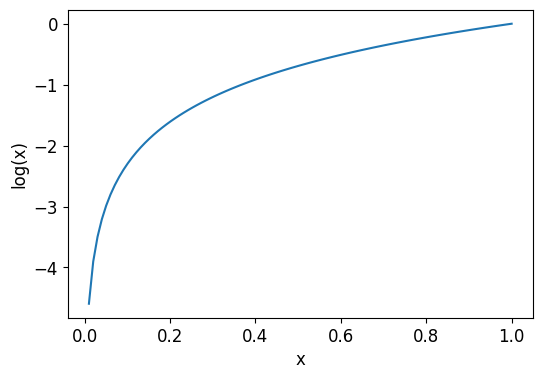

In [28]:
plot_function(torch.log, min=0, max=1, tx="x", ty="log(x)")

The function goes to ➖∞ as the probabilities approach zero. The loss function cares about differences between small numbers eg between 0.01 and 0.0001 where there are 2 orders of magnitude between both numbers despite both being very small in magnitude. We also care about computational efficiency, and computers have a hard time accurately representing increasingly smaller decimals. Taking the log helps on both fronts because it:
- extends the magnitude of differences between such small decimals. For example, $log_{10}(0.01) = -2$ and $log_{10}(0.0001) = -4$ means the difference between both numbers is 2 rather than $0.01 - 0.0001 = 0.0099$.
- changes multiplication and division operations into addition and subtraction respectively, according to the log identities: $log_{b}(x*y) = log_{b}(x) + log_{b}(y)$ and $log_{b}(\frac{x}{y}) = log_{b}(x) - log_{b}(y)$

However, the log function will always generate a negative value for the probabilities. This means quite simply, good loss values will be slightly negative, and bad loss values will be strongly negative. This would mean that reducing the loss would require us to *increase* high negative values by pushing them to become low negative values. Not very intuitive. We want the opposite i.e. good loss values should be slightly positive and bad loss values should be highly positive, so that minimizing the loss really is a case of reducing large positive numbers to smaller positive ones.

Achieving that is as simple as multiplying the log output by -1:

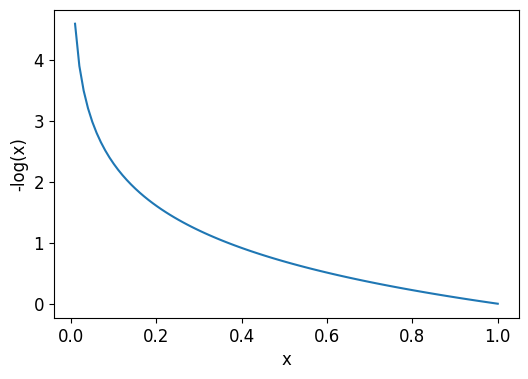

In [29]:
plot_function(lambda x: -1*torch.log(x), min=0, max=1, ty="-log(x)", tx="x")

As we've now seen, we took the negative log of the probabilities to get the loss values. This is why the cross-entropy loss function is also called the "negative log likelihood" loss function. Let's now see how this looks for the softmax-ed logits of the target labels:

In [30]:
sm_logits[idx, targ].unsqueeze(1), sm_logits[idx, targ].log().unsqueeze(1), -sm_logits[idx, targ].log().unsqueeze(1)

(tensor([[0.6025],
         [0.4979],
         [0.1332],
         [0.0034],
         [0.4041],
         [0.3661]]),
 tensor([[-0.5067],
         [-0.6973],
         [-2.0160],
         [-5.6958],
         [-0.9062],
         [-1.0048]]),
 tensor([[0.5067],
         [0.6973],
         [2.0160],
         [5.6958],
         [0.9062],
         [1.0048]]))

Once again, to have minimal loss, all the softmax-ed logits for the *correct* categories should be near `1`. As we can see, the values that are closest to `0` have the largest loss values.

**PyTorch notes**: 3 important things:
- the `log_softmax` method performs the softmax + log combination all at once
- the `nll_loss` method essentially just does the multiplication by -1, so it has to be used *after* using `log_softmax`
- using the `nn.CrossEntropyLoss` module returns a function that combines both `log_softmax` and `nll_loss`. As is the norm with pytorch, this behavior is also available directly on the functional namespace as `F.cross_entropy`

In [31]:
loss_func = nn.CrossEntropyLoss()
loss_func

CrossEntropyLoss()

In [32]:
loss_func(logits, targ), F.cross_entropy(logits, targ)

(tensor(1.8045), tensor(1.8045))

The function takes the mean of the results by default, so to see our previous values, we have to disable that behavior:

In [33]:
nn.CrossEntropyLoss(reduction="none")(logits, targ).unsqueeze(1), -sm_logits[idx, targ].log().unsqueeze(1)

(tensor([[0.5067],
         [0.6973],
         [2.0160],
         [5.6958],
         [0.9062],
         [1.0048]]),
 tensor([[0.5067],
         [0.6973],
         [2.0160],
         [5.6958],
         [0.9062],
         [1.0048]]))

> One interesting fact about cross-entropy loss is that its gradient is given by `softmax(a)-b` for a given function set of activations (`a`) and targets (`b`) that go into `cross_entropy(a,b)`. At the same time, `softmax(a)` is the activation of the final layer, as we saw earlier. This means the gradient is proportional to the difference between the predicted probabilities (from 0 to 1) and the target value (1). This is a linear relationship, so should thus lead to smoother training via SGD. The same thing happens with mean squared difference, where the gradient for $(a-b)^{2}$ is $2(a-b)$.

### Model interpretation

The loss function is intended to make SGD useful, not for humans to understand. For our own purposes, and specifically to see how the model performs for our real-world use-case, we need a metric that actually measures what we care about. Accuracy is a good starting point, and as we've seen from the last fine-tuning run, it's already looking promising. Let's visualize it a bit more clearly using a confusion matrix:

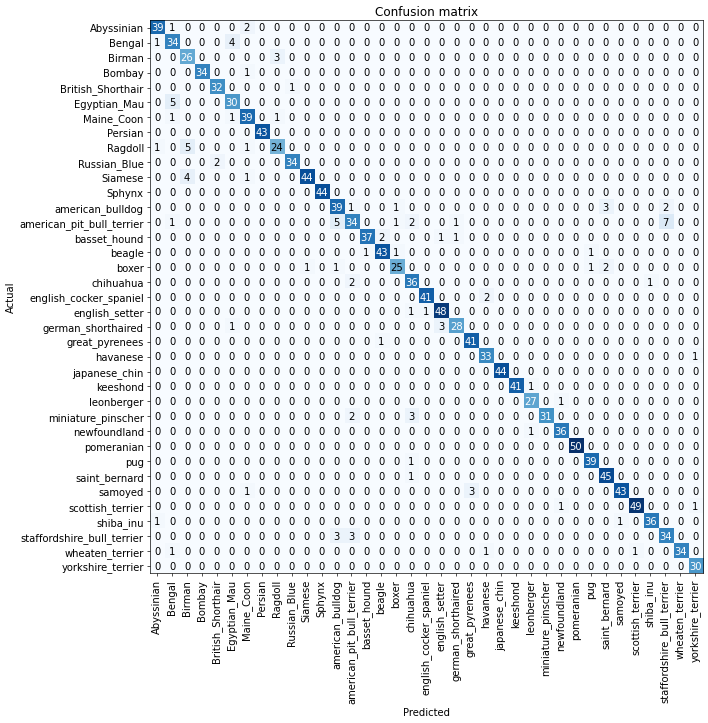

In [34]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix(figsize=(12,12), dpi=60)

That's a lot of data, but it's still quite clear that the model is getting the vast majority correct (in the validation set). Let's see where the errors are highest:

In [35]:
interp.most_confused(min_val=5)

[('american_pit_bull_terrier', 'staffordshire_bull_terrier', np.int64(7)),
 ('Egyptian_Mau', 'Bengal', np.int64(5)),
 ('Ragdoll', 'Birman', np.int64(5)),
 ('american_pit_bull_terrier', 'american_bulldog', np.int64(5))]

Some quick googling reveals that these species are actually hard to distinguish even by experts, so the model seems to be on the right track.

### Improving The Model

Let's start by exploring how to choose an appropriate learning rate.

#### Learning Rate Finder

A really low learning rate leads to slow learning that requires more epochs, which also increases the risk of overfitting to the data. But at the same time a high learning rate can worsen the model's performance. For example:

In [36]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(1, base_lr=0.1)

epoch,train_loss,valid_loss,error_rate,time
0,2.625891,4.875359,0.428281,00:38


epoch,train_loss,valid_loss,error_rate,time
0,3.752725,2.514294,0.702300,00:46


As that shows, the training loss actually got worse. That's because the model took a step that was too big. So even though it tried to go in the correct direction, it overshot the local minimum. Do that multiple times and we'll end up going further and further away.

To address this problem, we'll use a technique called a learning rate finder. This technique makes 1 pass over the data (i.e. 1 epoch), and for each mini-batch it uses a different learning rate. Starting with a learning rate so low that it's almost guaranteed to not overshoot, the first mini-batch is processed and its loss is generated. Then for the next mini-batch, the learning rate is increased by a particular ratio, eg 2 (i.e. a doubling). The mini-batch is processed and the loss calculated. Then the learning rate is increased by the same ratio, and the next mini-batch is processed, and so on and so forth. The learning rates and the losses are tracked throughout, such that by the end of the epoch, there'll be a clear picture of which learning rates had which losses. Here's how that looks:

<div></div>

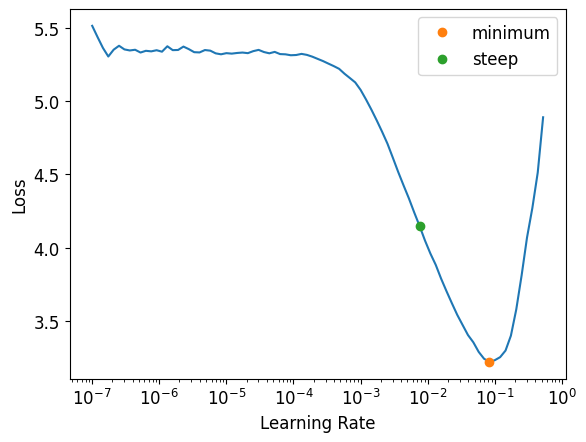

In [37]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
lr_minimum, lr_steep = learn.lr_find(suggest_funcs=(minimum, steep))

In [38]:
print(f'Minimum/10: {lr_minimum:.2e}; steepest point: {lr_steep:.2e}')

Minimum/10: 8.32e-03; steepest point: 7.59e-03


fastai recommends using either:
- one order of magnitude less than the learning rate with the lowest loss i.e. `lr_minimum`; OR
- the learning rate where the loss is reducing fastest i.e. where the gradient of the plot is steepest, which is `lr_steep`

Both of these will often tend towards the same values if the plot looks like the one above, and indeed the values above demonstrate this.

Let's use `lr_minimum`.

In [39]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fine_tune(2, base_lr=lr_minimum)

epoch,train_loss,valid_loss,error_rate,time
0,1.027735,0.545241,0.160352,00:36


epoch,train_loss,valid_loss,error_rate,time
0,0.853648,1.030022,0.224628,00:45
1,0.498035,0.306560,0.100135,00:45


Now we see a reduction in the loss as expected. Let's move on now to finetuning the weights of a pretrained model.

### Unfreezing and Transfer Learning

As we've already established, the final layer of a neural network is a matrix of linear functions and their corresponding weights and biases that are numbered to fit the number of output classes necessary for the classification task. That means this final layer, more than all the others, is tuned to the task that the model was trained for. The inner layers however learn more generalized features of images that are still useful for other image classification tasks. The whole idea of transfer learning is to take those inner layers and apply them to another classification task without losing the information they encode.

More concretely, this means the final layer of the pretrained model has to be discarded, and a new layer with random weights has to be put in place and then trained on the data for the new classification task. At the same time, because those inner layers have such strong results from their initial training, there's good reason to leave them as they are or change them very lightly to fit the new task.

So, to do the training, it's often best to focus on training only the weights of the new layers. It is therefore said that we are *freezing* the weights of the inner layers. The way to do this is to tell the optimizer, which is responsible for the gradient steps of calculating the gradients and updating the weights based on them, to only update the weights of the new layers.

The `fine_tune` method in fastai comes with the following default sensible behavior to get reasonably good results:
- freeze the inner layers and train the new outer layers over 1 epoch
- unfreeze all layers and then train them all together over the requested number of epochs

Good default behavior, but customizable. And we should try to customize to fit our needs. To see what we can customize, we'll inspect the source code of `fine_tune` and then go through some of its bundled functionality manually and individually.

In [40]:
learn.fine_tune??

Signature:
learn.fine_tune(
    epochs,
    base_lr=0.002,
    freeze_epochs=1,
    lr_mult=100,
    pct_start=0.3,
    div=5.0,
    *,
    lr_max=None,
    div_final=100000.0,
    wd=None,
    moms=None,
    cbs=None,
    reset_opt=False,
    start_epoch=0,
)
Source:   
@patch
@delegates(Learner.fit_one_cycle)
def fine_tune(self:Learner, epochs, base_lr=2e-3, freeze_epochs=1, lr_mult=100,
              pct_start=0.3, div=5.0, **kwargs):
    "Fine tune with `Learner.freeze` for `freeze_epochs`, then with `Learner.unfreeze` for `epochs`, using discriminative LR."
    self.freeze()
    self.fit_one_cycle(freeze_epochs, slice(base_lr), pct_start=0.99, **kwargs)
    base_lr /= 2
    self.unfreeze()
    self.fit_one_cycle(epochs, slice(base_lr/lr_mult, base_lr), pct_start=pct_start, div=div, **kwargs)
File:      /usr/local/lib/python3.12/dist-packages/fastai/callback/schedule.py
Type:      method


Notice a few things:
- it's indeed freezing the inner layers using `.freeze()`
- it uses `.fit_one_cycle()` to train only the new layers for the specified number of `freeze_epochs` (default `1` as mentioned earlier), with a learning rate that's a `slice` object (more on that soon)
- it reduces the learning rate then unfreezes all the layers
- then it trains all the layers again using `.fit_one_cycle()`, this time using the specified number of `epochs` and another different-looking `slice` object

Let's start by manually training the new layers for 3 epochs, using `.fit_one_cycle()`. We use `.fit_one_cycle()` because, as we will soon see, it adjusts the learning rate over the course of the training, starting from a lower value in the beginning, gradually increasing it in the first section of training, and then gradually reducing it in the last section of training. This is a good tactic for getting better results.

In [41]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, lr_minimum)

epoch,train_loss,valid_loss,error_rate,time
0,0.999283,0.824183,0.203654,00:36
1,0.731114,0.422226,0.132612,00:36
2,0.443240,0.289185,0.089986,00:37


Now we'll unfreeze all the layers.

In [42]:
learn.unfreeze()

Let's now check with `.lr_find()` again because we have more layers and we've already trained the new layers for a few epochs.

<div></div>

SuggestedLRs(minimum=4.365158383734525e-06, steep=8.31763736641733e-06)

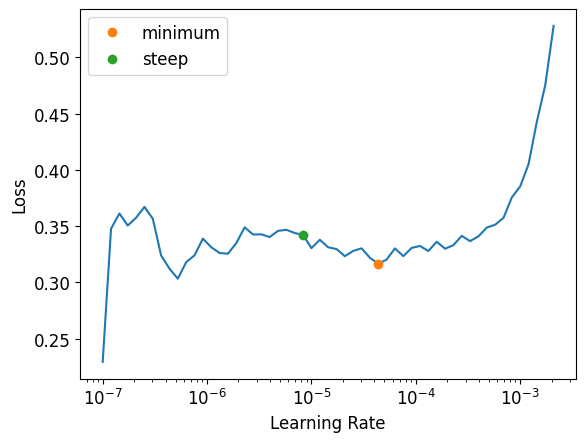

In [43]:
learn.lr_find(suggest_funcs=(minimum, steep))

This time around we don't have that big dip that clearly showed where the model had a lot of training left to do. That's because we've already done 3 epochs that have largely handled that part. The main thing now is to pick a value that comes well before that sharp rise. We'll use `1e-5`. Note that the steepest point is no longer useful here because it's pointing at a point in the curve that's not what we're looking for (because we already did the training). Let's train over 6 epochs.

In [44]:
learn.fit_one_cycle(6, 1e-5)

epoch,train_loss,valid_loss,error_rate,time
0,0.313073,0.264782,0.087957,00:46
1,0.278557,0.250825,0.080514,00:48
2,0.247311,0.238299,0.078484,00:47
3,0.240952,0.235892,0.077131,00:48
4,0.211152,0.232636,0.075101,00:48
5,0.208043,0.232526,0.073748,00:48


We've gotten better results, which is good. However, because we unfroze all the layers before this run, we implicitly used the same learning rate for all the layers of the model. That's not necessarily good because we already mentionned previously, the inner layers already got to a good place in the original training that produced the initial pretrained model. To get even better results, we should apply different (and likely smaller) learning rates to those existing layers. This is called using *discriminative learning rates*.

### Discriminative Learning Rates

As we've discussed already, we still care about the pre-trained weights. They are the results of a lot of optimization over a lot of images. More so, the innermost layers will be more applicable to our task than the outermost layers. Visualizations of the layers' features show that the inner layers have learned features like edges and gradients that will be applicable to most images, whereas the outer layers learn features that are more specific to the particular task. All of this makes it worth our while to train the inner layers with smaller learning rates to preserve what they already know, and train the outer layers with larger learning rates to cause them to learn newer things.

Note that the paper by [Jason Yosinski](https://arxiv.org/abs/1411.1792) doesn't use discriminative learning rates or directly demonstrate their effectiveness; rather, it demonstrates that retraining **all** the weights of a network (fine-tuning) after transfer learning (re-using pretrained weights) can lead to good results. It did this by highlighting how co-adaptation affects the performance of a model by showing that rigidly cutting off and freezing middle layers prevents the new layers from sufficiently adapting to the existing layers. It also highlighted that later layers of the model must be retrained if they're to be rendered useful to the new task, because keeping them frozen caused a dramatic loss in performance.

Fastai allows us to specify the learning rate range for discriminative learning by using a `slice` object. Fastai will use the starting value of the range as the learning rate of the first layer, and the last value as the learning rate of the final layer. Intermediate values will be calculated in a such a way that they are multiplicatively equidistant from each other.

We'll repeat the previous training using a learning rate range of 1e-6 to 1e-4.

In [45]:
learn = vision_learner(dls, resnet34, metrics=error_rate)
learn.fit_one_cycle(3, lr_minimum)
learn.unfreeze()
learn.fit_one_cycle(12, lr_max=slice(1e-6, 1e-4))

epoch,train_loss,valid_loss,error_rate,time
0,1.107517,0.917883,0.248309,00:40
1,0.714709,0.376672,0.113667,00:41
2,0.404515,0.270069,0.086604,00:40


epoch,train_loss,valid_loss,error_rate,time
0,0.302666,0.264382,0.082544,00:48
1,0.262282,0.253964,0.076455,00:48
2,0.267466,0.243883,0.077131,00:48
3,0.231714,0.237265,0.074425,00:48
4,0.222854,0.239063,0.079838,00:48
5,0.197787,0.234158,0.072395,00:48
6,0.184522,0.232868,0.076455,00:48
7,0.175737,0.227236,0.075778,00:48
8,0.166996,0.223039,0.072395,00:48
9,0.157065,0.219110,0.069012,00:48


Fine-tuning is working much better now. Let's visualize how the training and validation loss values change over time:

<Axes: title={'center': 'learning curve'}, xlabel='steps', ylabel='loss'>

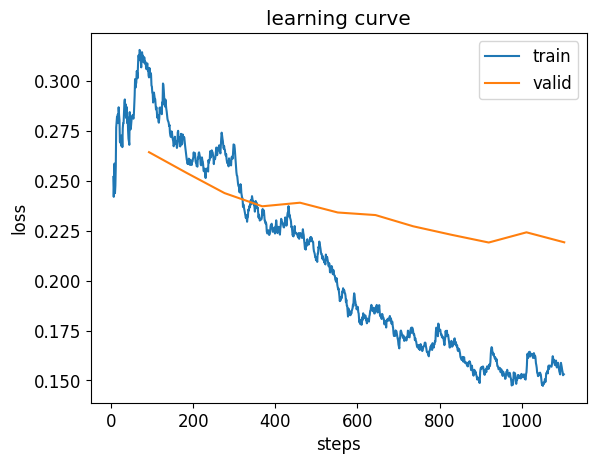

In [46]:
learn.recorder.plot_loss()

The training loss keeps improving, but the validation loss slows and may even get worse. This is the point at which the model is beginning to overfit the data. However, what matters is your chosen metric. If we're still seeing better results, then a slightly overfit model may not be such a bad thing.

Another important decision when training a model is how long to train for.

### Selecting the number of epochs